### Es 1
Hai a disposizione un file `data.csv` contenente dati mensili di traffico aereo con due colonne:

- `date`: data in formato `YYYY-MM` (mese/anno)
- `passengers`: numero di passeggeri per quel mese


Costruisci un modello di **regressione polinomiale** che approssima l’andamento del numero di passeggeri nel tempo.

1. Carica il dataset.
2. Convertilo in un formato numerico utilizzando una colonna `mese_numerico` che conti i mesi a partire da gennaio 1949.
3. Applica una regressione polinomiale (grado a tua scelta).
4. Calcola l’RMSE tra i valori reali e quelli predetti.
5. Visualizza i dati reali e la curva stimata con Plotly.

RMSE lineare: 71.1191019575337
RMSE polinomiale: 72.2196458281995


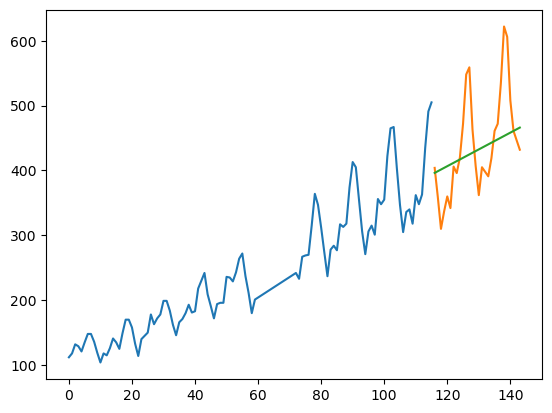

In [41]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import plotly.graph_objects as go
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

df=pd.read_csv('data.csv')
df['date'] = pd.to_datetime(df['date'])
start_date = pd.to_datetime("1949-01")
start_date
df["mese_numerico"] = (
    (df["date"].dt.year - start_date.year) * 12 +
    (df["date"].dt.month - start_date.month)
)

df=df.dropna(subset=['passengers']) # 1 passengers è NA


X=df[['mese_numerico']]
y=df['passengers']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,shuffle=False)
plt.plot(X_train,y_train)
plt.plot(X_test,y_test)

model_linear = LinearRegression()
    
#regressione lineare
model_linear.fit(X_train,y_train)
y_pred_linear = model_linear.predict(X_test)
plt.plot(X_test,y_pred_linear)

#calcolo del rmse
rmse = root_mean_squared_error(y_test, y_pred_linear)
print("RMSE lineare:", rmse)


#polinomiale
grado=2
poly = PolynomialFeatures(degree=grado)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
model_linear.fit(X_train_poly, y_train)
y_pred_poly = model_linear.predict(X_test_poly)

#rmse
rmse_poly = root_mean_squared_error(y_test, y_pred_poly)
print("RMSE polinomiale:", rmse_poly)


#proviamo plotly
df_test = df.iloc[len(X_train):].copy()
df_test['pred'] = y_pred_linear
df_test['pred_poly']=y_pred_poly

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df['date'],
    y=df['passengers'],
    mode='markers',
    name='Reale'
))

fig.add_trace(go.Scatter(
    x=df_test['date'],
    y=df_test['pred'],
    mode='lines',
    name='Predetto (lineare)'
))

fig.add_trace(go.Scatter(
    x=df_test['date'],
    y=df_test['pred_poly'],
    mode='lines',
    name='Polinomiale grado 3'
))

fig.show()
